In [13]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

Import my colony counts recorded in Excel

In [3]:
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Results 16 October.xlsx"
data = pd.read_excel(path)

#Set dose levels and used plating numbers
Dose_levels = [0, 2, 5, 8]
Plating_numbers = [500, 1000, 3000, 6000]

print(data)

    Flask nr  Count  Dose       Rad  Triplicate
0          1     74     5  Proton L           3
1          2     69     2         X           1
2          3     17     2  Proton H           2
3          4    112     0         P           1
4          5      1     8         X           3
5          6      4     5         X           1
6          7      1     8  Proton H           2
7          8     39     0         X           1
8          9      0     5  Proton H           1
9         10      8     0         X           2
10        11     40     2  Proton L           1
11        12      3     8  Proton L           1
12        13     33     2         X           3
13        14    108     2  Proton L           3
14        15     42     2  Proton H           3
15        16     44     5         X           2
16        17     38     5  Proton L           1
17        18     15     5         X           3
18        19      2     8         X           2
19        20     25     0         X     

In [4]:
def Perform_LQ_fit(doses, survival):
    #Generate LQ fit

    #inputs:
    #doses = list of used dose levels
    #survival = dictionary with survival data per dose level

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations
    
    def LQ_function(d, a, b):
        exponent = -(a*d + b*(np.square(d)))
        return exponent

    xvals = np.array(doses)
    yvals = np.array(list(survival.values()))
    yvals = np.log(yvals)

    p0 = (0.1, 0.1)

    popt, pcov = curve_fit(LQ_function, xvals, yvals, p0=p0, bounds=(0,1))
    
    return popt, LQ_function

In [5]:
def Parse_data(doselevels, platingnumbers, input):
    #Split colony counting data into cell survival per dose level

    #inputs:
    #doselevels = list of the used dose levels
    #platingnumbers = list of the plating numbers for each dose level
    #input = dataframe with the dose and count for each sample

    output_survival = {}
    output_std = {}

    output_df = pd.DataFrame(columns=['Dose', 'Count 1', 'Count 2', 'Count 3'])
    
    for i in range(len(doselevels)):
        dose = doselevels[i]
        plating_number = platingnumbers[i]

        #Isolate data from this dose level
        dose_level_data = input[input['Dose'] == dose]

        #Write to dataframe
        newrow = {}
        newrow['Dose'] = dose
        for row in dose_level_data.itertuples():
            trip = row.Triplicate
            newrow[f"Count {trip}"] = row.Count
        newrow = pd.DataFrame([newrow])
        output_df = pd.concat([output_df, newrow], ignore_index=True)

        #Find average colony count
        average_count = dose_level_data['Count'].mean()

        #Calculate survival
        if i == 0:
            #If we're on the control sample, store value
            control_survival = average_count/plating_number
        survival = (average_count/plating_number)/control_survival

        #Write survival to dictionary
        output_survival[f"{dose} Gy"] = survival
        output_std[f"{dose} Gy"] = (dose_level_data['Count'].std()/plating_number)/control_survival


    return output_survival, output_std, output_df


Plot data and generate LQ curve for X-rays

{'0 Gy': 1.0, '2 Gy': 0.7916666666666666, '5 Gy': 0.14583333333333334, '8 Gy': 0.004629629629629629}
{'0 Gy': 0.6468406123441677, '2 Gy': 0.6005639710583156, '5 Gy': 0.1434998494428599, '8 Gy': 0.0020046884346862004}
  Dose Count 1 Count 2 Count 3
0    0      39       8      25
1    2      69      12      33
2    5       4      44      15
3    8       1       2       1


Text(0, 0.5, 'Count')

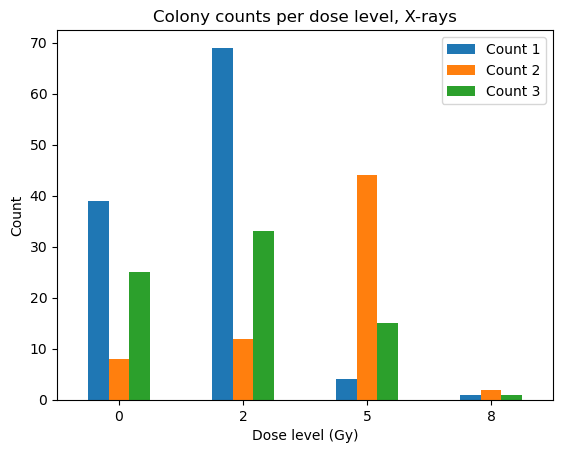

In [6]:
#Filter out X-ray results
X_ray_samples = data[data['Rad'] == 'X']

#Split per dose level
X_ray_survival, X_ray_survival_std, X_ray_df = Parse_data(Dose_levels, Plating_numbers, X_ray_samples)

print(X_ray_survival)
print(X_ray_survival_std)
print(X_ray_df)

#Make bar plot of colony counts
X_ray_df.plot(x="Dose", y=["Count 1", "Count 2", "Count 3"], kind="bar", rot=0)
plt.title('Colony counts per dose level, X-rays')
plt.xlabel('Dose level (Gy)')
plt.ylabel('Count')
    

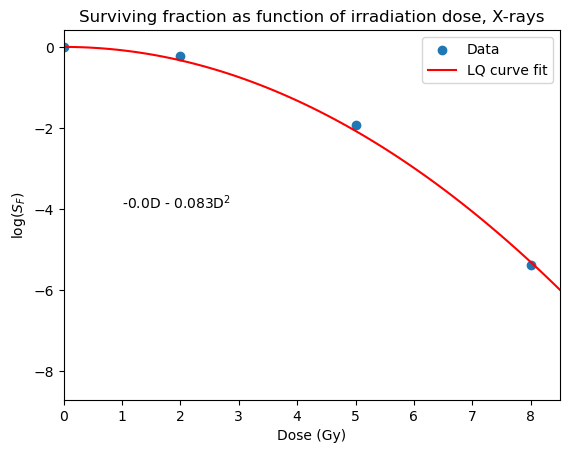

In [7]:
#Generate LQ fit plot
params_x, LQ_func = Perform_LQ_fit(Dose_levels, X_ray_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(X_ray_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), label='LQ curve fit', color = 'r')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, X-rays')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_x[0],3)}D - {round(params_x[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()

Plot data and generate LQ curve for protons low LET

{'0 Gy': 1.0, '2 Gy': 0.39189189189189183, '5 Gy': 0.08502252252252251, '8 Gy': 0.003378378378378378}
{'0 Gy': 0.16163342856629304, '2 Gy': 0.17476374535645356, '5 Gy': 0.03463181151955356, '8 Gy': 0.001462880749635876}
  Dose Count 1 Count 2 Count 3
0    0     112     103      81
1    2      40      84     108
2    5      38      39      74
3    8       3       6       3


Text(0, 0.5, 'Count')

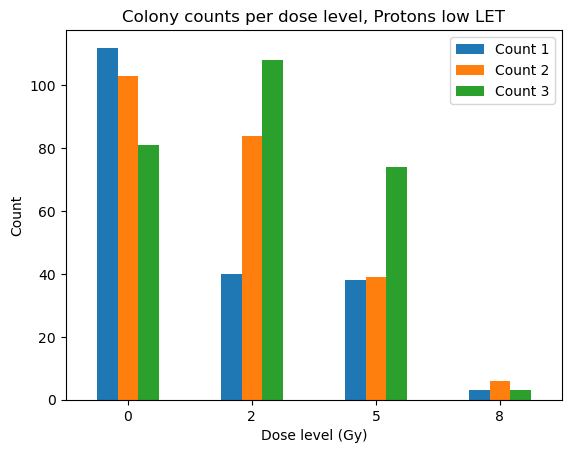

In [8]:
#Filter out proton low LET results
Proton_low_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton H')]

#Split per dose level
Proton_low_survival, Proton_low_survival_std, Proton_low_df = Parse_data(Dose_levels, Plating_numbers, Proton_low_samples)

print(Proton_low_survival)
print(Proton_low_survival_std)
print(Proton_low_df)

#Make bar plot of colony counts
Proton_low_df.plot(x="Dose", y=["Count 1", "Count 2", "Count 3"], kind="bar", rot=0)
plt.title('Colony counts per dose level, Protons low LET')
plt.xlabel('Dose level (Gy)')
plt.ylabel('Count')


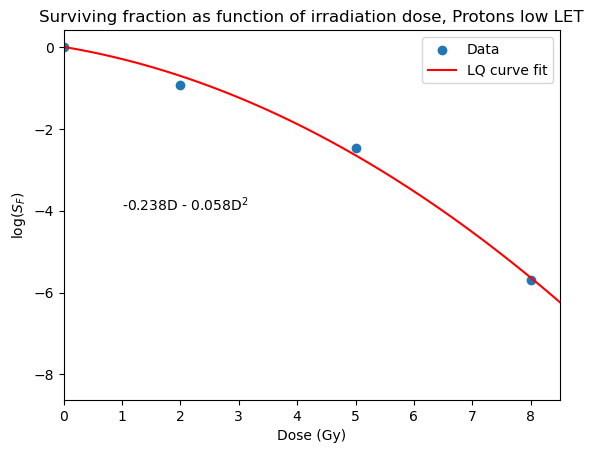

In [9]:
#Generate LQ fit plot
params_lp, LQ_func = Perform_LQ_fit(Dose_levels, Proton_low_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(Proton_low_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_lp[0], params_lp[1]), label='LQ curve fit', color='r')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, Protons low LET')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_lp[0],3)}D - {round(params_lp[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()

Plot data and generate LQ curve for protons high LET

{'0 Gy': 1.0, '2 Gy': 0.20270270270270271, '5 Gy': 0.04842342342342343, '8 Gy': 0.015484234234234232}
{'0 Gy': 0.16163342856629304, '2 Gy': 0.11183146870294211, '5 Gy': 0.0795235634201016, '8 Gy': 0.02390864160536278}
  Dose Count 1 Count 2 Count 3
0    0     112     103      81
1    2      61      17      42
2    5       0       3      83
3    8       3       1      51


Text(0, 0.5, 'Count')

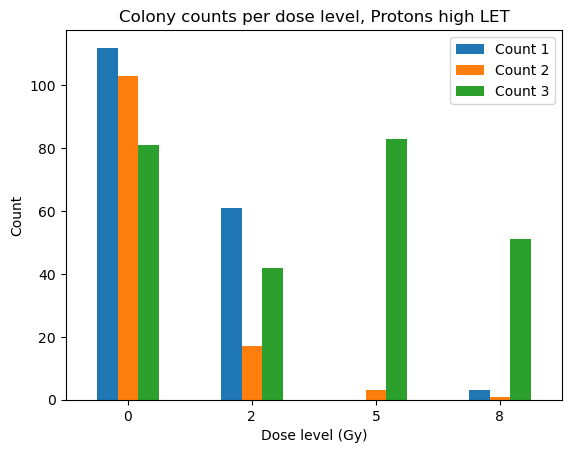

In [10]:
#Filter out proton high LET results
Proton_high_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton L')]

#Split per dose level
Proton_high_survival, Proton_high_survival_std, Proton_high_df = Parse_data(Dose_levels, Plating_numbers, Proton_high_samples)

print(Proton_high_survival)
print(Proton_high_survival_std)
print(Proton_high_df)

#Make bar plot of colony counts
Proton_high_df.plot(x="Dose", y=["Count 1", "Count 2", "Count 3"], kind="bar", rot=0)
plt.title('Colony counts per dose level, Protons high LET')
plt.xlabel('Dose level (Gy)')
plt.ylabel('Count')


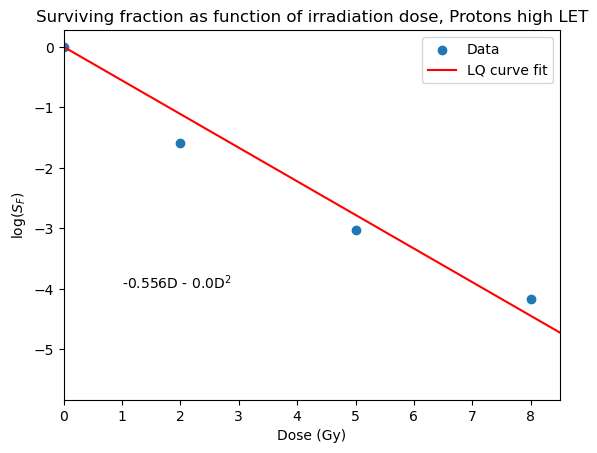

In [11]:
#Generate LQ fit plot
params_hp, LQ_func = Perform_LQ_fit(Dose_levels, Proton_high_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(Proton_high_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_hp[0], params_hp[1]), label='LQ curve fit', color='r')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, Protons high LET')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_hp[0],3)}D - {round(params_hp[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()

Plot all data together

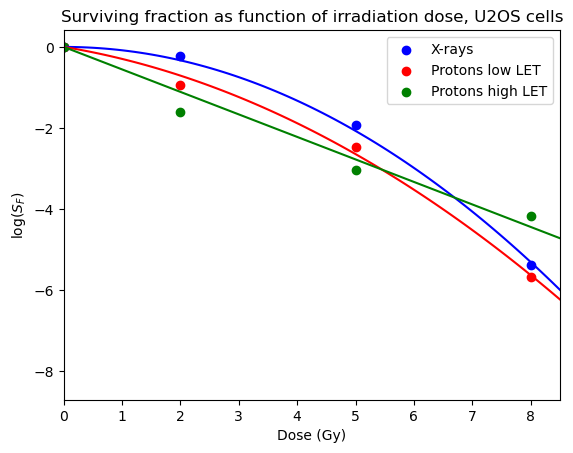

In [12]:
plt.scatter(Dose_levels, np.log(np.array(list(X_ray_survival.values()))), color='b', label='X-rays')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color = 'b')

plt.scatter(Dose_levels, np.log(np.array(list(Proton_low_survival.values()))), label='Protons low LET', color='r')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_lp[0], params_lp[1]), color='r')

plt.scatter(Dose_levels, np.log(np.array(list(Proton_high_survival.values()))), label='Protons high LET', color='g')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_hp[0], params_hp[1]), color='g')

plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, U2OS cells')
plt.xlim([0, 8.5])
plt.legend()

Calculate RBE from LQ curve fits for a given survival level.

In [29]:
#Set survival leve
Survival_level = 0.37

xdata = np.linspace(0,8,1000)

#Survival data from LQ fit for each
ydata_x = LQ_func(xdata, params_x[0], params_x[1])
ydata_lp = LQ_func(xdata, params_lp[0], params_lp[1])
ydata_hp = LQ_func(xdata, params_hp[0], params_hp[1])

#Define interpol objects
interp_x = interp1d(ydata_x, xdata)
interp_lp = interp1d(ydata_lp, xdata)
interp_hp = interp1d(ydata_hp, xdata)

#Interpolate the survival level from lq fits
D_x = interp_x(np.log(Survival_level))
print('D_x: ' + str(round(float(D_x),2)) + ' Gy')
D_lp = interp_lp(np.log(Survival_level))
print('D_lp: ' + str(round(float(D_lp),2)) + ' Gy')
D_hp = interp_hp(np.log(Survival_level))
print('D_hp: ' + str(round(float(D_hp),2)) + ' Gy')

#RBE
RBE_lp = D_x/D_lp
print('RBE low LET: ' + str(round(RBE_lp,2)))

RBE_hp = D_x/D_hp
print('RBE low LET: ' + str(round(RBE_hp,2)))

D_x: 3.46 Gy
D_lp: 2.57 Gy
D_hp: 1.79 Gy
RBE low LET: 1.35
RBE low LET: 1.93
